In [5]:
import pandas as pd 

In [6]:
df = pd.read_csv('heart_disease_uci.csv')
cols_do_drop = ['id', 'dataset']
df = df.drop(columns=cols_do_drop)
df['num'] = df['num'] > 0
df['num'] = df['num'].astype(int)

In [7]:
df.isna().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
num_cols = ['age', 'trestbps', 'chol', 'fbs', 'exang', 'oldpeak', 'thalch']
cat_cols =['sex', 'cp', 'restecg', 'slope', 'thal']

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(unknown_value=-1, handle_unknown='use_encoded_value'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols), 
    ('cat', cat_transformer, cat_cols)
], remainder='passthrough')

In [11]:
lambda_values = [0, 5, 20, 50, 100, 500, 1000]

for l in lambda_values: 
    clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        max_depth=10, n_estimators=500, learning_rate=0.05, reg_lambda=l, reg_alpha=0, gamma=0
    ))
])
    clf.fit(X_train, y_train)
    clf_pred = clf.predict(X_test) 
    training_score_clf = clf.score(X_train, y_train)
    test_score_clf = clf.score(X_test, y_test)
    print (f'lambda={l} | Train: {training_score_clf:.4f} | Test: {test_score_clf:.4f}')

# After trying all the lambda values, we can witness that reg_lambda=500 is our sweet spot. 
# We keep it, moving on to gamma

lambda=0 | Train: 1.0000 | Test: 0.8152
lambda=5 | Train: 0.9986 | Test: 0.8424
lambda=20 | Train: 0.9783 | Test: 0.8478
lambda=50 | Train: 0.9389 | Test: 0.8315
lambda=100 | Train: 0.9103 | Test: 0.8370
lambda=500 | Train: 0.8668 | Test: 0.8587
lambda=1000 | Train: 0.8492 | Test: 0.8370


In [12]:
gamma_values = [0, 1, 5, 10, 20]
for g in gamma_values: 
    clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        max_depth=10, n_estimators=500, learning_rate=0.05, reg_lambda=500, reg_alpha=0, gamma=g
    ))
])
    clf.fit(X_train, y_train)
    clf_pred = clf.predict(X_test) 
    training_score_clf = clf.score(X_train, y_train)
    test_score_clf = clf.score(X_test, y_test)
    print (f'gamma={g} | Train: {training_score_clf:.4f} | Test: {test_score_clf:.4f}')

# After trying different values for the gamma parameter, it can be seen that the sweet spot is 0

gamma=0 | Train: 0.8668 | Test: 0.8587
gamma=1 | Train: 0.8302 | Test: 0.8478
gamma=5 | Train: 0.7568 | Test: 0.8098
gamma=10 | Train: 0.7473 | Test: 0.8098
gamma=20 | Train: 0.5530 | Test: 0.5543


In [13]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        max_depth=10, n_estimators=500, learning_rate=0.05, reg_lambda=500, reg_alpha=0, gamma=0
    ))
])

clf.fit(X_train, y_train) 
clf_pred = clf.predict(X_test)
training_score_clf = clf.score(X_train, y_train)
test_score_clf = clf.score(X_test, y_test)

print (f'| Train: {training_score_clf:.4f} | Test: {test_score_clf:.4f}')
# I wrote 2 loops to find the best values for lambda and gamma, with the former hitting its sweet spot at 500 and the latter hitting plateau at 0

| Train: 0.8668 | Test: 0.8587


In [28]:
extracted_clf = clf.named_steps['model']
X_test_prepped = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

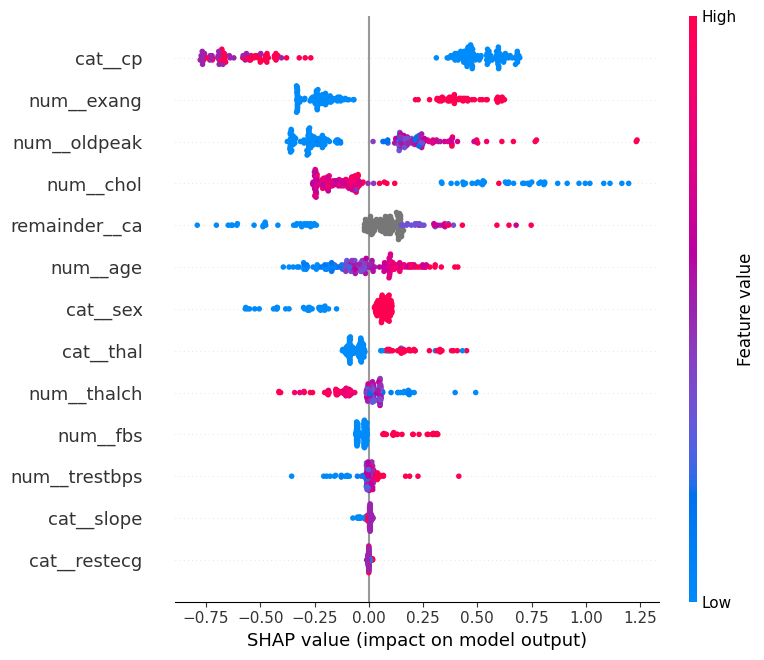

In [29]:
from shap import TreeExplainer, summary_plot

explainer = TreeExplainer(extracted_clf)
shap_values = explainer.shap_values(X_test_prepped)

summary_plot(shap_values, X_test_prepped, feature_names=feature_names)

In [31]:
encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
print(encoder.categories_)

[array(['Female', 'Male'], dtype=object), array(['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina'],
      dtype=object), array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object), array(['downsloping', 'flat', 'upsloping'], dtype=object), array(['fixed defect', 'normal', 'reversable defect'], dtype=object)]
